In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import math

import import_ipynb
from graph_functions import *

In [ ]:
# number of graphs for n=4 a=1: 1
# number of graphs for n=6 a=2: 2
# number of graphs for n=8 a=3: 1
# number of graphs for n=10 a=4: 2
# number of graphs for n=12 a=5: 1
# number of graphs for n=14 a=6: 2
# number of graphs for n=16 a=7: 1
# number of graphs for n=18 a=8: 2

In [ ]:
def partitions(n, k, p=1):
	if n < p: return
	elif k == 0:
		if n == 0: yield []
	elif k == 1:
		if n != 0: yield [n]
	else:
		for r in partitions(n-p, k-1, p):
			yield [p] + r
		yield from partitions(n, k, p + 1)


def infect_cycle(n, k):
	for l in range(1, k + 1):
		for r in partitions(k, l):
			for p in partitions(n - k, l):
				s = []
				for b, b2 in zip(r, p):
					# s += "1" * int(b) + "0" * int(b2)
					s.extend([1] * int(b))
					s.extend([0] * int(b2))
				yield s

number of graphs for n=10 : 2
[(<networkx.classes.graph.Graph object at 0x7fdb419dcfa0>, 10, 2)]
[1, 0, 0, 0, 0, 1, 0, 0, 0, 0]


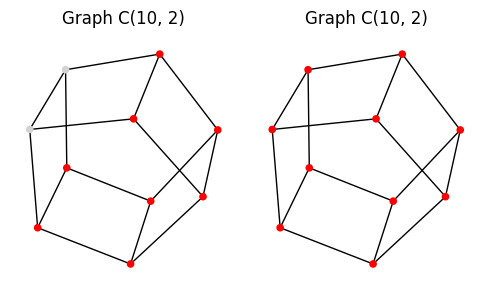

[1, 0, 0, 0, 0, 1, 1, 0, 0, 0]
[1, 0, 0, 0, 0, 1, 0, 1, 0, 0]


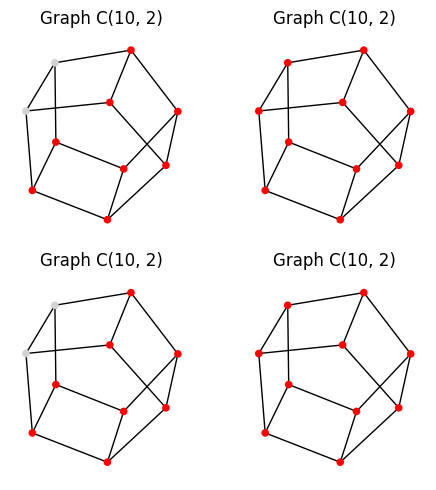

[1, 0, 0, 0, 0, 1, 1, 1, 0, 0]
[1, 0, 0, 0, 0, 1, 0, 1, 1, 0]
[1, 1, 0, 0, 0, 1, 1, 0, 0, 0]
[1, 1, 0, 0, 0, 1, 0, 1, 0, 0]
[1, 0, 1, 0, 0, 1, 1, 0, 0, 0]
[1, 0, 1, 0, 0, 1, 0, 1, 0, 0]


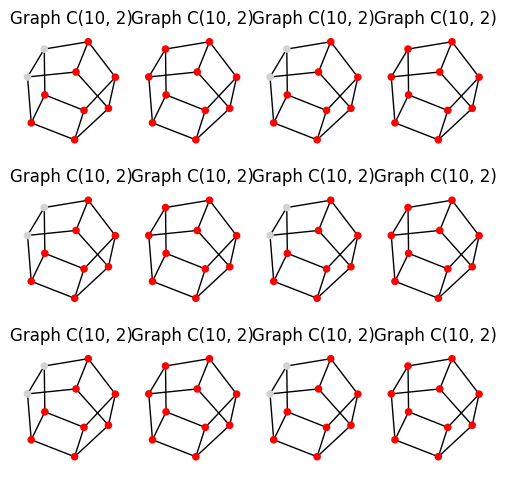

[1, 0, 0, 0, 0, 1, 1, 1, 1, 0]
[1, 1, 0, 0, 0, 1, 1, 1, 0, 0]
[1, 1, 0, 0, 0, 1, 0, 1, 1, 0]
[1, 0, 1, 0, 0, 1, 1, 1, 0, 0]
[1, 0, 1, 0, 0, 1, 0, 1, 1, 0]


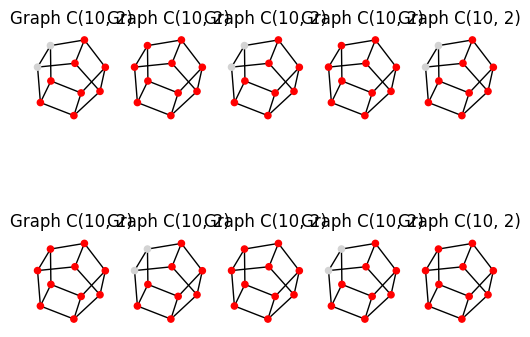

[1, 1, 0, 0, 0, 1, 1, 1, 1, 0]
[1, 0, 1, 0, 0, 1, 1, 1, 1, 0]
[1, 1, 1, 0, 0, 1, 1, 1, 0, 0]
[1, 1, 1, 0, 0, 1, 0, 1, 1, 0]
[1, 0, 1, 1, 0, 1, 1, 1, 0, 0]
[1, 0, 1, 1, 0, 1, 0, 1, 1, 0]


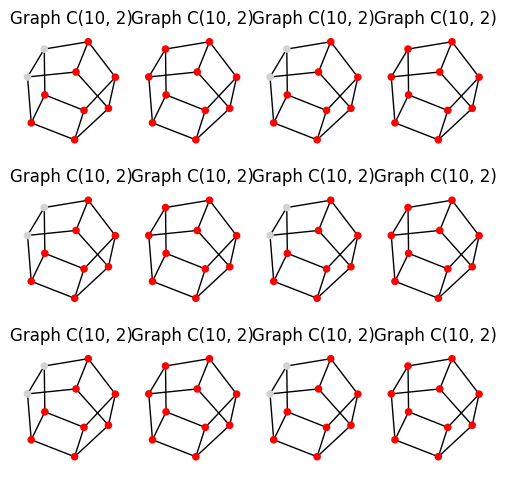

[1, 1, 1, 0, 0, 1, 1, 1, 1, 0]
[1, 0, 1, 1, 0, 1, 1, 1, 1, 0]


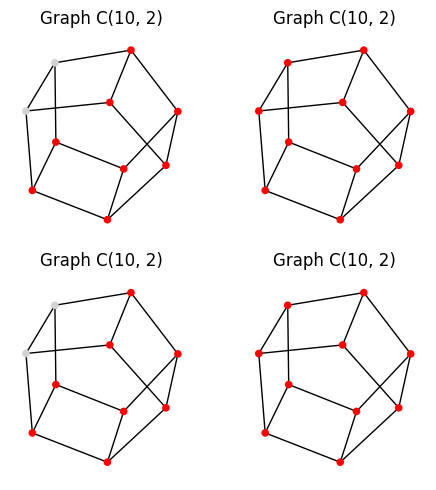

[1, 1, 1, 1, 0, 1, 1, 1, 1, 0]


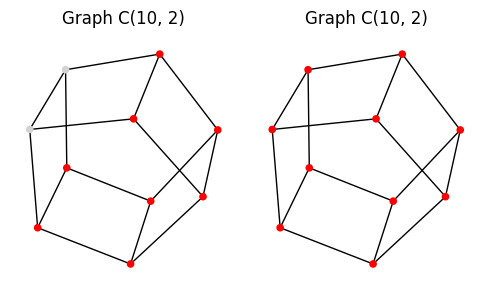

ValueError: Number of columns must be a positive integer, not 0

<Figure size 500x500 with 0 Axes>

In [ ]:
graphs = generate_graphs(10)[1:]

def generate_infection_mobious(G):
    pass

def generate_infection_prism(G):
    n = len(G.nodes)
    for k in range(2, n):
        # print("k=", k)
        k_list = []
        for k1, k2 in partitions(k, 2):
            for c1 in infect_cycle(n/2, k1):
                for c2 in infect_cycle(n/2, k2):
                    # for shift in range(n/2):
                    # yield c1 + c2
                    k_list.append(c1 + c2)
        yield k, k_list


print(graphs)


for G, n, a in graphs:
    for k, mask_list in generate_infection_prism(G):
        H = infect_graph(G, i)
        
        unique_infections = []
        for i_mask in mask_list:
            iG, _, _ = fully_endemic(H)
            unique_infections.append((H, n, a))
            print(i_mask)
            unique_infections.append((iG, n, a))
        
        display_graphs(unique_infections, figsize=(5, 5), show_titles=True, force_row=False, with_labels=True)

# def generate_infection(G, n, k):
# 	# mobius loop
# 	if a == 1:
# 		generate_infection_mobious(G, n, k)
# 	else:
# 		generate_infection_prism(G, n, k)